In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from vllm import LLM, SamplingParams

In [2]:
# --- Fix Colab / IPython iostream fileno issue ---
if not hasattr(sys.stdout, "fileno") or callable(getattr(sys.stdout, "fileno", None)):
    try:
        sys.stdout.fileno()
    except (AttributeError, Exception):
        # Redirect fileno calls to the real standard output stream descriptor (FD 1)
        sys.stdout.fileno = lambda: 1

In [3]:
# Configuration
MODEL_NAME = "facebook/opt-125m"
GPU_UTILIZATION = 0.5
MAX_NUM_SEQS = 16
MAX_TOKENS = 64

BATCH_SIZES = [4, 8, 16, 32, 64]
NUM_RUNS = 3
PROMPT_TEXT = "Explain what is vLLM used for and why"

# Engine Initialization

print("Initializing vLLM Engine...")
llm = LLM(
    model=MODEL_NAME,
    gpu_memory_utilization=GPU_UTILIZATION,
    max_num_seqs=MAX_NUM_SEQS,
    trust_remote_code=True,
)
sampling_params = SamplingParams(max_tokens=MAX_TOKENS)
print("Engine successfully loaded.\n")

Initializing vLLM Engine...
INFO 08-24 16:58:44 [api_utils.py:273] non-default args: {'trust_remote_code': True, 'gpu_memory_utilization': 0.5, 'max_num_seqs': 16, 'disable_log_stats': True, 'model': 'facebook/opt-125m'}


INFO 08-24 16:58:47 [model.py:645] Resolved architecture: OPTForCausalLM
INFO 08-24 16:58:47 [model.py:1883] Using max model len 2048
INFO 08-24 16:58:47 [scheduler.py:242] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 08-24 16:58:47 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
(EngineCore pid=10499) INFO 08-24 16:58:49 [core.py:121] Initializing a V1 LLM engine (v0.27.1) with config: model='facebook/opt-125m', speculative_config=None, tokenizer='facebook/opt-125m', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.float16, max_seq_len=2048, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=None, quantization_config=None, enforce_eager=False

Loading pt checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


(EngineCore pid=10499) INFO 08-24 16:58:59 [default_loader.py:430] Loading weights took 0.32 seconds
(EngineCore pid=10499) INFO 08-24 16:59:00 [model_runner.py:329] Model loading took 0.24 GiB and 6.094662 seconds
(EngineCore pid=10499) WARNING 08-24 16:59:00 [topk_topp_sampler.py:69] FlashInfer top-p/top-k sampling unavailable: unsupported compute capability 7.5; falling back. Set VLLM_USE_FLASHINFER_SAMPLER=0 to silence.
(EngineCore pid=10499) INFO 08-24 16:59:02 [caching.py:335] reconstructed serializable fn from standalone compile artifacts. num_artifacts=3 num_submods=13
(EngineCore pid=10499) INFO 08-24 16:59:02 [decorators.py:311] Directly load AOT compilation from path /root/.cache/vllm/torch_compile_cache/torch_aot_compile/9b0d8b0eb591744dd35bdc40c3a6b6b9b6cb6bf529687c9b35d8a60ad51936e4/rank_0_0/model
(EngineCore pid=10499) INFO 08-24 16:59:02 [monitor.py:53] torch.compile took 0.16 s in total
(EngineCore pid=10499) INFO 08-24 16:59:02 [monitor.py:81] Initial profiling/warmup

Capturing CUDA graphs (FULL): 100%|██████████| 5/5 [00:00<00:00, 46.19it/s]


(EngineCore pid=10499) INFO 08-24 16:59:08 [model_runner.py:791] Graph capturing finished in 3 secs, took 0.06 GiB
(EngineCore pid=10499) INFO 08-24 16:59:08 [gpu_worker.py:789] Free memory on device (14.46/14.56 GiB) on startup. Desired GPU memory utilization is (0.5, 7.28 GiB). Actual usage is 0.32 GiB for consumed memory (weights + non-torch), 0.09 GiB for peak activation, and 0.06 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=7155841024` (6.66 GiB) to fit into requested memory, or `--kv-cache-memory=14864414720` (13.84 GiB) to fully utilize gpu memory. Current kv cache memory in use is 6.87 GiB.
(EngineCore pid=10499) INFO 08-24 16:59:22 [jit_monitor.py:79] Kernel JIT monitor activated; monitored JIT compilations during inference will use mode=warn.
(EngineCore pid=10499) INFO 08-24 16:59:23 [core.py:348] init engine (profile, create kv cache, warmup model) took 22.95 s (compilation: 0.16 s)
(EngineCore pid=10499) INFO 08-24 16:59:23 [kerne

In [4]:
# Warmup Run
print("Executing warmup run...")
llm.generate([PROMPT_TEXT], sampling_params, use_tqdm=False)
print("Warmup complete.\n")

Executing warmup run...
Warmup complete.



In [7]:
# Configuration

MODEL_NAME = "facebook/opt-125m"
GPU_UTILIZATION = 0.5
MAX_NUM_SEQS = 64
MAX_TOKENS = 64

BATCH_SIZES = [4, 8, 16, 32, 64]
NUM_RUNS = 10         # Increased run count for meaningful percentile calculations
PROMPT_TEXT = "Explain what vLLM is and why is used?"

# Benchmarking Loop

results = []

for batch_size in BATCH_SIZES:
    prompts = [PROMPT_TEXT] * batch_size
    latencies = []
    total_tokens_list = []

    print(f"Benchmarking Batch Size: {batch_size}")

    for run in range(NUM_RUNS):
        start_time = time.perf_counter()
        outputs = llm.generate(prompts, sampling_params, use_tqdm=False)
        end_time = time.perf_counter()

        latency = end_time - start_time
        latencies.append(latency)

        total_tokens = sum(len(output.outputs[0].token_ids) for output in outputs)
        total_tokens_list.append(total_tokens)

    # Calculate Latency Percentiles
    p50_latency = np.percentile(latencies, 50)
    p95_latency = np.percentile(latencies, 95)
    p99_latency = np.percentile(latencies, 99)

    avg_tokens = np.mean(total_tokens_list)
    throughput_tokens_per_sec = avg_tokens / p50_latency  # Throughput relative to median latency
    throughput_req_per_sec = batch_size / p50_latency

    results.append({
        "Batch Size": batch_size,
        "p50 Latency (s)": round(p50_latency, 4),
        "p90 Latency (s)": round(p95_latency, 4),
        "p99 Latency (s)": round(p99_latency, 4),
        "Total Tokens": int(avg_tokens),
        "Tokens/Sec": round(throughput_tokens_per_sec, 2),
        "Requests/Sec": round(throughput_req_per_sec, 2)
    })

Benchmarking Batch Size: 4
Benchmarking Batch Size: 8
Benchmarking Batch Size: 16
Benchmarking Batch Size: 32
Benchmarking Batch Size: 64



--- Benchmark Summary (Latency Percentiles) ---

 Batch Size  p50 Latency (s)  p90 Latency (s)  p99 Latency (s)  Total Tokens  Tokens/Sec  Requests/Sec
          4           0.1962           0.2095           0.2148           206     1053.86         20.38
          8           0.2029           0.2153           0.2159           396     1953.21         39.43
         16           0.2558           0.2760           0.2800           793     3103.09         62.54
         32           0.4893           0.6305           0.6542          1595     3261.72         65.40
         64           1.0084           1.2281           1.2430          3177     3151.13         63.47


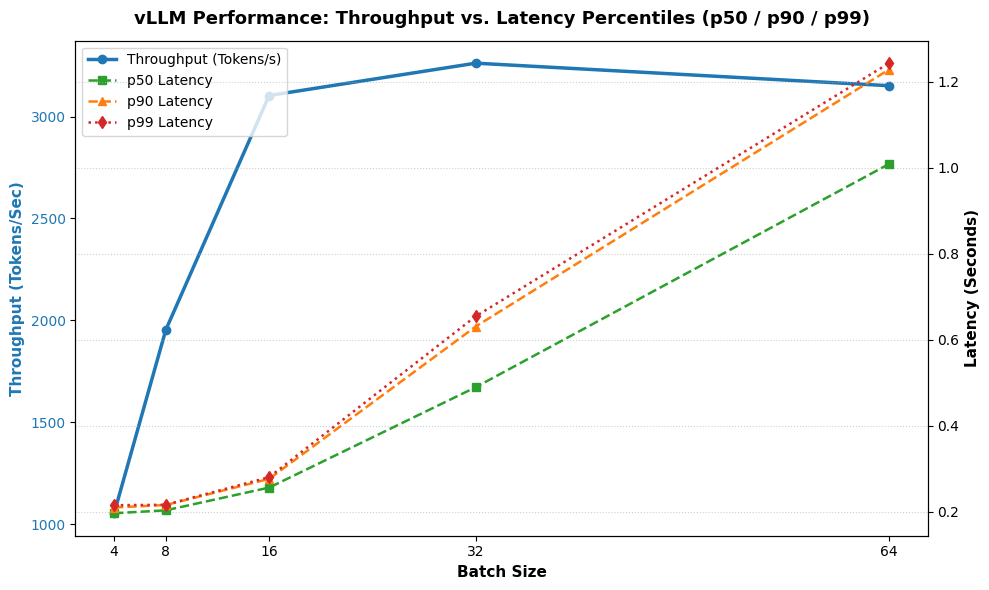

In [10]:
# Results DataFrame & Visualization

df_results = pd.DataFrame(results)

print("\n--- Benchmark Summary (Latency Percentiles) ---")
print(df_results.to_string(index=False))

# Export results to CSV for repo artifacts
df_results.to_csv("vllm_benchmark_results.csv", index=False)

# Plotting Throughput vs. Latency Percentiles

fig, ax1 = plt.subplots(figsize=(10, 6))

# Left Y-Axis: Throughput (Tokens/Sec)
color_tp = 'tab:blue'
ax1.set_xlabel('Batch Size', fontweight='bold', fontsize=11)
ax1.set_ylabel('Throughput (Tokens/Sec)', color=color_tp, fontweight='bold', fontsize=11)
ax1.plot(
    df_results['Batch Size'],
    df_results['Tokens/Sec'],
    marker='o',
    color=color_tp,
    linewidth=2.5,
    label='Throughput (Tokens/s)'
)
ax1.tick_params(axis='y', labelcolor=color_tp)
ax1.set_xticks(df_results['Batch Size'])

# Right Y-Axis: Latency Percentiles (p50, p90, p99)
ax2 = ax1.twinx()
ax2.set_ylabel('Latency (Seconds)', color='black', fontweight='bold', fontsize=11)

ax2.plot(
    df_results['Batch Size'],
    df_results['p50 Latency (s)'],
    marker='s',
    color='tab:green',
    linestyle='--',
    linewidth=1.8,
    label='p50 Latency'
)
ax2.plot(
    df_results['Batch Size'],
    df_results['p90 Latency (s)'],
    marker='^',
    color='tab:orange',
    linestyle='--',
    linewidth=1.8,
    label='p90 Latency'
)
ax2.plot(
    df_results['Batch Size'],
    df_results['p99 Latency (s)'],
    marker='d',
    color='tab:red',
    linestyle=':',
    linewidth=1.8,
    label='p99 Latency'
)
ax2.tick_params(axis='y', labelcolor='black')

# Combined Legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True)

plt.title('vLLM Performance: Throughput vs. Latency Percentiles (p50 / p90 / p99)', fontsize=13, fontweight='bold', pad=12)
fig.tight_layout()
plt.grid(True, linestyle=':', alpha=0.6)

# Save artifact for README / repository display
plt.savefig("vllm_benchmark_percentiles_plot.png", dpi=300)
plt.show()